# Phase 4 — CNN From Scratch

Goal: train a minimal from-scratch CNN end-to-end on the full dataset (Colab GPU),
establish a baseline, then iterate deliberately (batchnorm, dropout, augmentation,
depth) against that baseline -- one change at a time, each compared back to this run,
not against each other. Uses the exact harness (`src/training/`) validated in
Phase 3, unmodified.

The class-imbalance question left open in Phase 2/3 is resolved empirically here:
this first run is **unweighted** on purpose, so `per_class_recall` shows what the
36x imbalance actually costs before deciding whether weighted loss or
`make_weighted_sampler` (both already implemented) is worth adding.

In [1]:
# Colab only: mount Drive and cd into the synced project folder.
# Safe to run locally too -- the import fails there and this cell is skipped.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "/content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project"
except ImportError:
    pass

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project


In [2]:
import sys, os

# Walk up from cwd to the project root (marked by configs/config.yaml) and put it on
# sys.path. Plain os.getcwd() is not reliable here -- it depends on how the kernel was
# launched (VS Code's Jupyter extension defaults to the notebook's own folder, not the
# project root).
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "configs", "config.yaml")):
    _parent = os.path.dirname(_root)
    if _parent == _root:
        raise RuntimeError("Could not find project root (configs/config.yaml) above " + os.getcwd())
    _root = _parent
sys.path.append(_root)

from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn

from src.utils.config import load_config
from src.utils.seed import seed_everything
from src.utils.device import get_device
from src.data import splits, transforms as T, dataset as D
from src.data.fetch_data import fetch_dataset
from src.models.cnn import SimpleCNN
from src.training.trainer import train_model
from src.training.checkpoint import load_checkpoint
from src.training import engine
from src.training.metrics import plot_confusion_matrix

cfg = load_config()
seed_everything(cfg["seed"])
device = get_device(cfg["training"]["device"])
print("Environment:", cfg["env"], "| Device:", device)

fetch_dataset(cfg)  # no-op if already downloaded

Environment: colab | Device: cuda
Cloning https://github.com/spMohanty/PlantVillage-Dataset.git (sparse checkout: raw/color only) ...
Done. 38 class folders at /content/dataset/PlantVillage/color


PosixPath('/content/dataset/PlantVillage/color')

## 1. Load Phase 2's fixed split

Reuses the split and `class_to_idx` cached by `02_data_pipeline.ipynb` unchanged --
Phase 4 must not recompute a split, or later phases stop being comparable
(`CLAUDE.md`).

In [3]:
DATA_PATH = cfg["data"]["path"]
ARTIFACTS_DIR = cfg["data"]["artifacts_dir"]

splits_path = Path(ARTIFACTS_DIR) / "splits.csv"
class_to_idx_path = Path(ARTIFACTS_DIR) / "class_to_idx.json"

if not splits_path.exists() or not class_to_idx_path.exists():
    raise FileNotFoundError(
        f"{splits_path} or {class_to_idx_path} missing -- run notebooks/02_data_pipeline.ipynb first."
    )

splits_df = pd.read_csv(splits_path)
class_to_idx = splits.build_class_to_idx(DATA_PATH, cache_path=str(class_to_idx_path))
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"Loaded split: {len(splits_df)} images, {num_classes} classes")
splits_df["split"].value_counts()

Loaded split: 54305 images, 38 classes


,count
split,
train,38012
test,8147
val,8146


## 2. Dataloaders -- full dataset

Unlike Phase 3's smoke test (a tiny per-class subset used only to validate the
harness's plumbing), this uses the **full** fixed split -- meant to run on Colab
GPU, not locally (local is CPU-only, fine for the cells above but not for a real
training run).

In [4]:
train_transform = T.get_train_transforms(cfg)
eval_transform = T.get_eval_transforms(cfg)

loaders = D.make_dataloaders(
    splits_df,
    class_to_idx,
    train_transform,
    eval_transform,
    batch_size=cfg["dataloader"]["batch_size"],
    num_workers=cfg["dataloader"]["num_workers"],
    data_path=DATA_PATH,
)

for split, loader in loaders.items():
    print(f"{split}: {len(loader.dataset)} images, {len(loader)} batches")

train: 38012 images, 1188 batches
val: 8146 images, 255 batches
test: 8147 images, 255 batches


## 3. Model, loss, optimizer

`SimpleCNN` (`src/models/cnn.py`): three conv blocks (channels doubling as spatial
size halves), global average pool, linear head -- no batchnorm/dropout yet,
deliberately, so later additions have this baseline to compare against.

Loss is **unweighted** `CrossEntropyLoss` for this first run -- see the top-of-notebook
note on why the imbalance-handling decision is deferred to after seeing this
baseline's `per_class_recall`, not decided upfront.

In [5]:
model = SimpleCNN(num_classes).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Parameters: 98,150


## 4. Train

`max_epochs=30` is a generous ceiling, not a target -- `early_stopping_patience: 7`
on `macro_f1` (`configs/config.yaml`) stops training automatically once it stalls.

In [6]:
checkpoints_dir = Path(cfg["logging"]["checkpoints_dir"]) / "phase4_simplecnn_baseline"
resume_path = checkpoints_dir / "last.pt"
if resume_path.exists():
    print(f"Found checkpoint from an earlier attempt, resuming from {resume_path}")

history = train_model(
    model, loaders, criterion, optimizer, device,
    run_name="phase4_simplecnn_baseline", cfg=cfg, class_to_idx=class_to_idx, max_epochs=30,
    resume_from=resume_path if resume_path.exists() else None,
)
pd.DataFrame(history)

Found checkpoint from an earlier attempt, resuming from /content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project/experiments/checkpoints/phase4_simplecnn_baseline/last.pt
Resumed from /content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project/experiments/checkpoints/phase4_simplecnn_baseline/last.pt: starting at epoch 30, best macro_f1 so far = 0.9591


""


## 5. Verify checkpoint round-trip, then evaluate on the held-out test set

Same round-trip check as Phase 3: confirm `best.pt` reloads into a **fresh** model
instance and reproduces the metric it was saved with -- then use that reloaded model
for the real held-out test-set evaluation (not the val set used during training/early
stopping), since val was already used to pick `best.pt` and is not a fair final
number.

In [7]:
checkpoints_dir = Path(cfg["logging"]["checkpoints_dir"]) / "phase4_simplecnn_baseline"
best_path = checkpoints_dir / "best.pt"
assert best_path.exists()

fresh_model = SimpleCNN(num_classes).to(device)
payload = load_checkpoint(best_path, fresh_model, optimizer=None, map_location=device)
assert payload["class_to_idx"] == class_to_idx, "class_to_idx did not round-trip!"
print(f"Reloaded checkpoint from epoch {payload['epoch']}, best val {cfg['training']['checkpoint_metric']}={payload['best_metric']:.4f}")

test_metrics = engine.evaluate(fresh_model, loaders["test"], criterion, device, num_classes)
print(f"Test accuracy: {test_metrics['accuracy']:.4f} | Test macro_f1: {test_metrics['macro_f1']:.4f}")

Reloaded checkpoint from epoch 29, best val macro_f1=0.9616


eval:   0%|          | 0/255 [00:00<?, ?it/s]

Test accuracy: 0.9682 | Test macro_f1: 0.9591


## 6. Confusion matrix (test set)

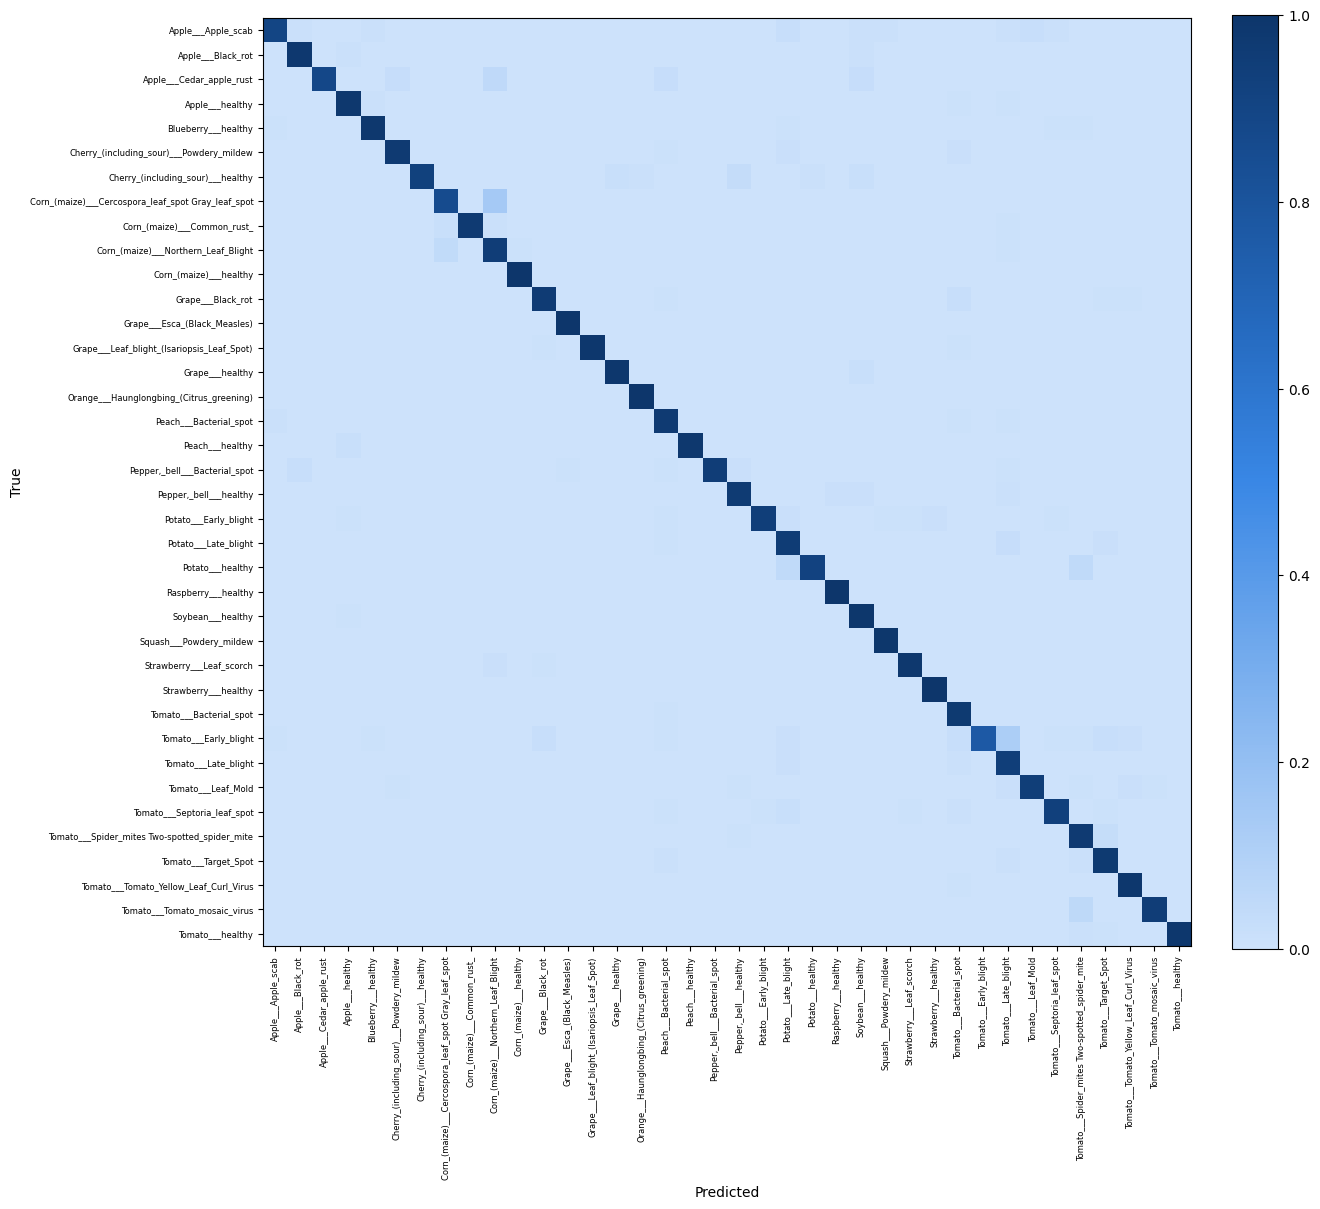

In [8]:
class_names = [idx_to_class[i] for i in range(num_classes)]
plot_confusion_matrix(test_metrics["confusion_matrix"], class_names)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

## 7. Per-class recall vs. train-set frequency

The empirical answer to the question Phase 2/3 deferred: does the 36x imbalance
meaningfully hurt minority-class recall on an *unweighted* baseline? If the worst
recall scores line up with the smallest train-set classes, weighted loss /
`make_weighted_sampler` becomes the next deliberate iteration. If not, adding
weighting would just be unnecessary complexity.

In [9]:
recall_series = pd.Series(
    test_metrics["per_class_recall"], index=[idx_to_class[i] for i in range(num_classes)]
).sort_values()

train_counts = splits_df[splits_df["split"] == "train"]["class"].value_counts()
comparison = pd.DataFrame({"train_count": train_counts, "test_recall": recall_series}).sort_values("train_count")

print("Lowest test recall (worst-performing classes):")
print(recall_series.head(10))
comparison

Lowest test recall (worst-performing classes):
Tomato___Early_blight                                 0.766667
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    0.857143
Apple___Cedar_apple_rust                              0.880952
Apple___Apple_scab                                    0.894737
Potato___healthy                                      0.913043
Cherry_(including_sour)___healthy                     0.921875
Tomato___Septoria_leaf_spot                           0.928302
Potato___Early_blight                                 0.940000
Tomato___Late_blight                                  0.940767
Tomato___Leaf_Mold                                    0.944056
dtype: float64


,train_count,test_recall
Potato___healthy,106,0.913043
Apple___Cedar_apple_rust,192,0.880952
Peach___healthy,252,0.981481
Raspberry___healthy,260,1.000000
Tomato___Tomato_mosaic_virus,261,0.946429
Grape___healthy,296,0.984375
Strawberry___healthy,319,1.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,359,0.857143
Apple___Black_rot,435,0.978495
Apple___Apple_scab,441,0.894737


## Summary & implications for the next iteration

In [10]:
print(f"Baseline test accuracy: {test_metrics['accuracy']:.4f}")
print(f"Baseline test macro_f1: {test_metrics['macro_f1']:.4f}")
print(f"Worst-recall class: {recall_series.index[0]} (recall={recall_series.iloc[0]:.3f}, train_count={int(train_counts.get(recall_series.index[0], 0))})")
print(f"Best-recall class: {recall_series.index[-1]} (recall={recall_series.iloc[-1]:.3f})")

Baseline test accuracy: 0.9682
Baseline test macro_f1: 0.9591
Worst-recall class: Tomato___Early_blight (recall=0.767, train_count=700)
Best-recall class: Raspberry___healthy (recall=1.000)


Takeaways:

- **Baseline test accuracy: 96.82%, test macro-F1: 95.91%** (best val macro-F1 0.9616
  at epoch 29/30 -- ran the full `max_epochs=30` ceiling, early stopping never
  triggered). Strong for a deliberately minimal, unregularized model -- consistent
  with PlantVillage-color being a well-known "easy" benchmark, not a sign of a
  problem. Real-world generalization is untested (see the optional Phase 9).
- **The 36x imbalance does not cleanly explain the worst-performing classes.**
  `Tomato___Early_blight` (recall 0.767, a *mid-range* 700 train images) is worse than
  `Potato___healthy` (recall 0.913, only 106 images). The confusion matrix shows why:
  misclassified `Tomato___Early_blight` images are disproportionately predicted as
  `Tomato___Late_blight` -- same pattern for two Corn diseases. The model is confusing
  visually similar diseases *within* the same species, not failing uniformly on rare
  classes. That points at model capacity/normalization as a more targeted next step
  than weighted loss / `make_weighted_sampler` -- imbalance handling stays available,
  just not yet clearly justified by this evidence.
- **Decision (see `PHASES.md`): iterate through all three candidates** -- batchnorm,
  augmentation, and added depth -- as separate runs compared back to this baseline,
  before starting Phase 5. Next: `phase4_simplecnn_batchnorm`.

## Iteration 1 — BatchNorm

Testing `SimpleCNNBatchNorm` (`src/models/cnn.py`) against the baseline above --
same data, same split, same loss (unweighted `CrossEntropyLoss`), same optimizer
config (Adam, lr=1e-3), same `max_epochs`/early-stopping settings. The only change
is `BatchNorm2d` after each conv layer. Run name `phase4_simplecnn_batchnorm` keeps
this fully separate from the baseline's logs/checkpoints.

Specifically targeting the baseline's weakest pattern: `Tomato___Early_blight` being
disproportionately confused with `Tomato___Late_blight` (see the baseline confusion
matrix above) -- does BatchNorm's more stable training let the model pick up on the
finer distinguishing features between similar diseases?

In [11]:
from src.models.cnn import SimpleCNNBatchNorm

model_bn = SimpleCNNBatchNorm(num_classes).to(device)
print(f"Parameters: {sum(p.numel() for p in model_bn.parameters()):,}")

optimizer_bn = torch.optim.Adam(model_bn.parameters(), lr=1e-3)

Parameters: 98,374


In [12]:
checkpoints_dir_bn = Path(cfg["logging"]["checkpoints_dir"]) / "phase4_simplecnn_batchnorm"
resume_path_bn = checkpoints_dir_bn / "last.pt"
if resume_path_bn.exists():
    print(f"Found checkpoint from an earlier attempt, resuming from {resume_path_bn}")

history_bn = train_model(
    model_bn, loaders, criterion, optimizer_bn, device,
    run_name="phase4_simplecnn_batchnorm", cfg=cfg, class_to_idx=class_to_idx, max_epochs=30,
    resume_from=resume_path_bn if resume_path_bn.exists() else None,
)
pd.DataFrame(history_bn)

Found checkpoint from an earlier attempt, resuming from /content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project/experiments/checkpoints/phase4_simplecnn_batchnorm/last.pt
Resumed from /content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project/experiments/checkpoints/phase4_simplecnn_batchnorm/last.pt: starting at epoch 30, best macro_f1 so far = 0.9700


""


### Verify checkpoint round-trip, then evaluate on the held-out test set

Same check as the baseline.

In [13]:
best_path_bn = checkpoints_dir_bn / "best.pt"
assert best_path_bn.exists()

fresh_model_bn = SimpleCNNBatchNorm(num_classes).to(device)
payload_bn = load_checkpoint(best_path_bn, fresh_model_bn, optimizer=None, map_location=device)
assert payload_bn["class_to_idx"] == class_to_idx, "class_to_idx did not round-trip!"
print(f"Reloaded checkpoint from epoch {payload_bn['epoch']}, best val {cfg['training']['checkpoint_metric']}={payload_bn['best_metric']:.4f}")

test_metrics_bn = engine.evaluate(fresh_model_bn, loaders["test"], criterion, device, num_classes)
print(f"Test accuracy: {test_metrics_bn['accuracy']:.4f} | Test macro_f1: {test_metrics_bn['macro_f1']:.4f}")

Reloaded checkpoint from epoch 28, best val macro_f1=0.9700


eval:   0%|          | 0/255 [00:00<?, ?it/s]

Test accuracy: 0.9731 | Test macro_f1: 0.9645


### Confusion matrix (test set)

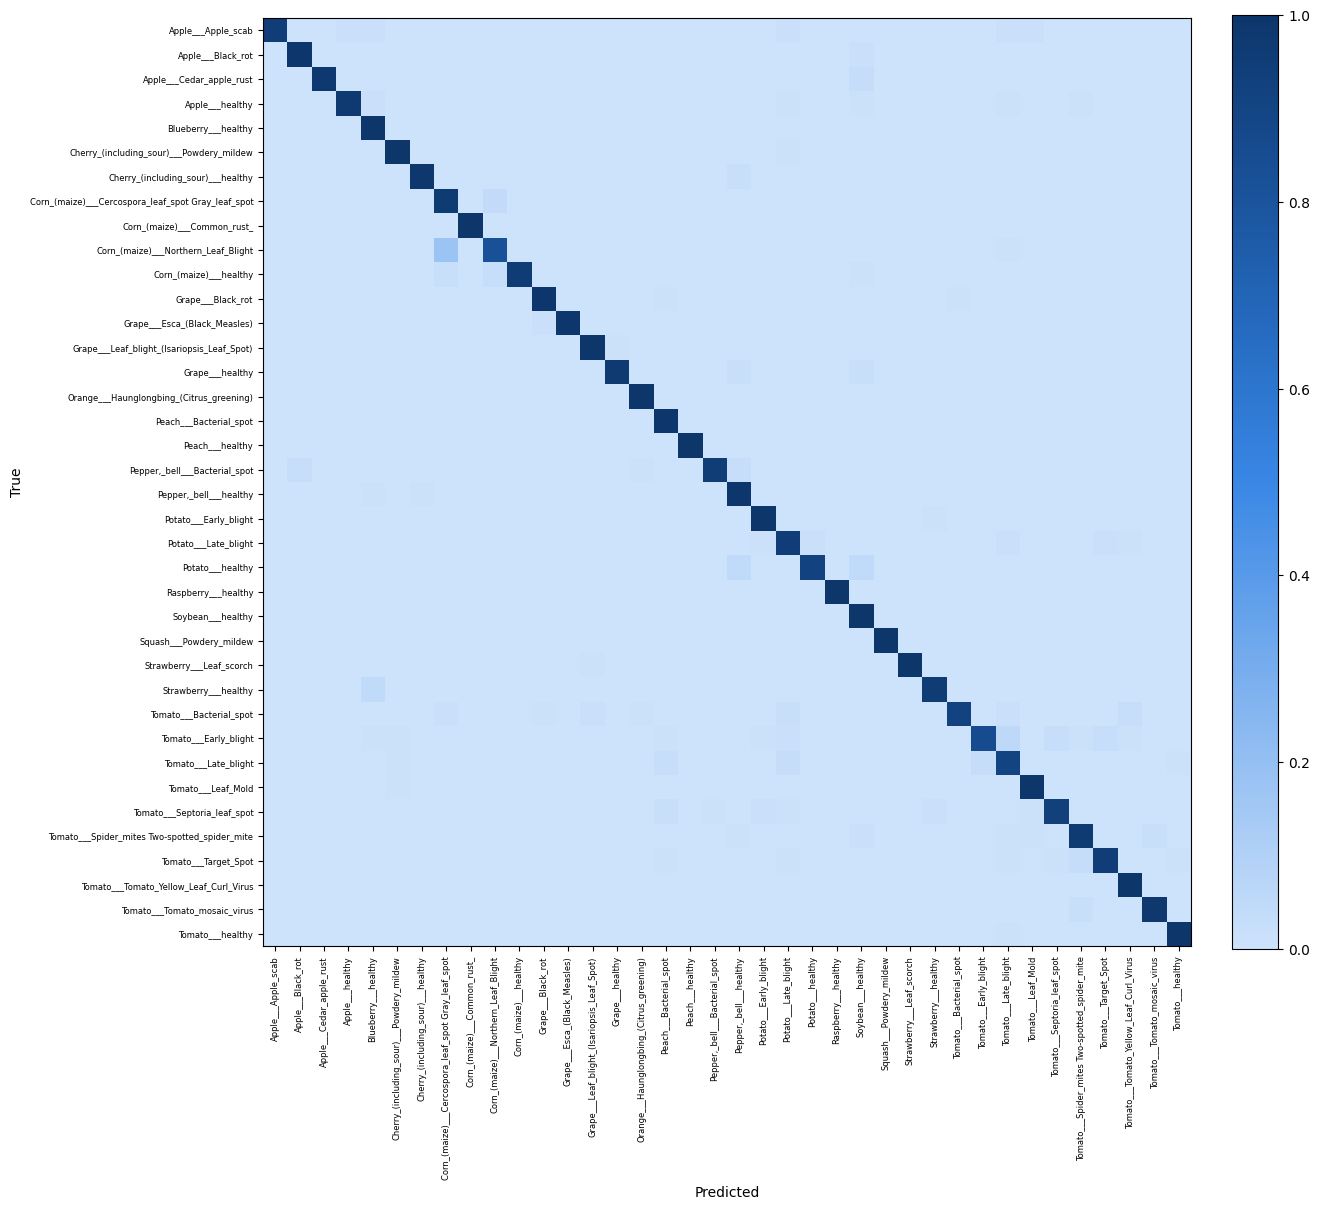

In [14]:
plot_confusion_matrix(test_metrics_bn["confusion_matrix"], class_names)
plt.tight_layout()
plt.show()

### Per-class recall vs. baseline

Direct comparison against the baseline run above -- same test set, same classes.
Specifically checking whether `Tomato___Early_blight` (the baseline's worst class)
improved.

In [15]:
recall_series_bn = pd.Series(
    test_metrics_bn["per_class_recall"], index=[idx_to_class[i] for i in range(num_classes)]
)

recall_comparison = pd.DataFrame({
    "baseline_recall": recall_series,
    "batchnorm_recall": recall_series_bn,
})
recall_comparison["delta"] = recall_comparison["batchnorm_recall"] - recall_comparison["baseline_recall"]
recall_comparison = recall_comparison.sort_values("delta")

print(f"Baseline:  test accuracy={test_metrics['accuracy']:.4f} | test macro_f1={test_metrics['macro_f1']:.4f}")
print(f"BatchNorm: test accuracy={test_metrics_bn['accuracy']:.4f} | test macro_f1={test_metrics_bn['macro_f1']:.4f}")
print(f"\nTomato___Early_blight recall: baseline={recall_series['Tomato___Early_blight']:.3f} -> batchnorm={recall_series_bn['Tomato___Early_blight']:.3f}")

print("\nBiggest recall drops (batchnorm worse than baseline):")
print(recall_comparison.head(5))
print("\nBiggest recall gains (batchnorm better than baseline):")
print(recall_comparison.tail(5))

Baseline:  test accuracy=0.9682 | test macro_f1=0.9591
BatchNorm: test accuracy=0.9731 | test macro_f1=0.9645

Tomato___Early_blight recall: baseline=0.767 -> batchnorm=0.853

Biggest recall drops (batchnorm worse than baseline):
                                     baseline_recall  batchnorm_recall  \
Corn_(maize)___Northern_Leaf_Blight         0.945578          0.816327   
Tomato___Bacterial_spot                     0.971787          0.912226   
Corn_(maize)___healthy                      1.000000          0.954286   
Strawberry___healthy                        1.000000          0.956522   
Tomato___Late_blight                        0.940767          0.902439   

                                        delta  
Corn_(maize)___Northern_Leaf_Blight -0.129252  
Tomato___Bacterial_spot             -0.059561  
Corn_(maize)___healthy              -0.045714  
Strawberry___healthy                -0.043478  
Tomato___Late_blight                -0.038328  

Biggest recall gains (batchnorm bett

Takeaways:

- **BatchNorm test accuracy: 97.31% | test macro-F1: 96.45%** (baseline: 96.82% /
  95.91% -- +0.49pp accuracy, +0.54pp macro-F1). Ran the full 30-epoch ceiling again,
  best val macro-F1 0.9700 at epoch 28.
- **`Tomato___Early_blight` recall improved 0.767 -> 0.853 (+8.7pp)** -- the biggest
  gain of all 38 classes. `Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot`
  improved even more (0.857 -> 0.961, +10.4pp), the second-biggest gain. Both were the
  two specific classes this iteration targeted -- the hypothesis (more stable
  training helps separate visually-similar same-species diseases) held.
- **Not a uniform win, though.** `Corn_(maize)___Northern_Leaf_Blight` dropped
  12.9pp (0.946 -> 0.816, the single biggest drop) -- notably, that's the exact class
  `Gray_leaf_spot` was being confused *as* in the baseline, so this reads less like
  "the confusion was fixed" and more like "the decision boundary between those two
  moved," trading one class's recall for the other's. Same likely story with
  `Tomato___Late_blight` (-3.8pp) as `Early_blight` improved. Two previously-perfect
  classes (`Corn_(maize)___healthy`, `Strawberry___healthy`) also slipped a few
  points -- plausibly ordinary run-to-run variance (single run, not seed-averaged)
  rather than a systematic BatchNorm effect.
- **Overall: keep it.** Macro-F1 -- the metric chosen specifically for the class
  imbalance -- improved, and improved via the predicted mechanism, not by accident.
  Worth carrying BatchNorm into the depth iteration rather than testing depth against
  the plain baseline.
- Next: `phase4_simplecnn_augmented` (data augmentation variant), compared back to
  this baseline same as this iteration was.

## Iteration 2 — Stronger Augmentation

Testing whether stronger augmentation improves on the **plain baseline**
(`SimpleCNN`, not the BatchNorm variant) -- testing this factor in isolation, same as
BatchNorm was, before deciding how to combine whichever factors help for the depth
iteration.

Strengthened knobs only, not a new augmentation type (keeps this one variable):
`rotation_degrees` 15 -> 30, `color_jitter` brightness/contrast/saturation
0.1 -> 0.2 each. `horizontal_flip_prob` stays at 0.5 -- already the natural max for a
binary flip.

Tested via a **notebook-local config copy**, not a change to `configs/config.yaml` --
`src/data/transforms.py` documents preprocessing as "held fixed through Phase 8" so
every phase's comparison stays valid, so the shared config only changes if this run
actually justifies it. Run name `phase4_simplecnn_augmented`.

Less certain than BatchNorm going in: the baseline's train/val loss didn't show
strong overfitting to begin with, and stronger color jitter could plausibly blur the
same subtle color/texture cues that distinguish similar diseases -- a real
experiment, not a predicted win.

In [16]:
import copy

cfg_strong_aug = copy.deepcopy(cfg)
cfg_strong_aug["augmentation"]["rotation_degrees"] = 30
cfg_strong_aug["augmentation"]["color_jitter"] = {"brightness": 0.2, "contrast": 0.2, "saturation": 0.2}

train_transform_strong = T.get_train_transforms(cfg_strong_aug)
# eval_transform is unchanged -- augmentation only ever applies at train time, and
# test-set evaluation below reuses the baseline's own loaders["test"] directly

loaders_aug = D.make_dataloaders(
    splits_df,
    class_to_idx,
    train_transform_strong,
    eval_transform,
    batch_size=cfg["dataloader"]["batch_size"],
    num_workers=cfg["dataloader"]["num_workers"],
    data_path=DATA_PATH,
)

In [17]:
model_aug = SimpleCNN(num_classes).to(device)
print(f"Parameters: {sum(p.numel() for p in model_aug.parameters()):,}")

optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

Parameters: 98,150


In [18]:
checkpoints_dir_aug = Path(cfg["logging"]["checkpoints_dir"]) / "phase4_simplecnn_augmented"
resume_path_aug = checkpoints_dir_aug / "last.pt"
if resume_path_aug.exists():
    print(f"Found checkpoint from an earlier attempt, resuming from {resume_path_aug}")

history_aug = train_model(
    model_aug, loaders_aug, criterion, optimizer_aug, device,
    run_name="phase4_simplecnn_augmented", cfg=cfg, class_to_idx=class_to_idx, max_epochs=30,
    resume_from=resume_path_aug if resume_path_aug.exists() else None,
)
pd.DataFrame(history_aug)

Found checkpoint from an earlier attempt, resuming from /content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project/experiments/checkpoints/phase4_simplecnn_augmented/last.pt
Resumed from /content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project/experiments/checkpoints/phase4_simplecnn_augmented/last.pt: starting at epoch 30, best macro_f1 so far = 0.9524


""


### Verify checkpoint round-trip, then evaluate on the held-out test set

Same check as the previous runs. Evaluated on the baseline's own `loaders["test"]`
(unaugmented in every run) rather than `loaders_aug["test"]` -- both use the same
`eval_transform` and the same test rows, so they're equivalent, but reusing the
original directly removes any possibility of doubt about that.

In [19]:
best_path_aug = checkpoints_dir_aug / "best.pt"
assert best_path_aug.exists()

fresh_model_aug = SimpleCNN(num_classes).to(device)
payload_aug = load_checkpoint(best_path_aug, fresh_model_aug, optimizer=None, map_location=device)
assert payload_aug["class_to_idx"] == class_to_idx, "class_to_idx did not round-trip!"
print(f"Reloaded checkpoint from epoch {payload_aug['epoch']}, best val {cfg['training']['checkpoint_metric']}={payload_aug['best_metric']:.4f}")

test_metrics_aug = engine.evaluate(fresh_model_aug, loaders["test"], criterion, device, num_classes)
print(f"Test accuracy: {test_metrics_aug['accuracy']:.4f} | Test macro_f1: {test_metrics_aug['macro_f1']:.4f}")

Reloaded checkpoint from epoch 25, best val macro_f1=0.9524


eval:   0%|          | 0/255 [00:00<?, ?it/s]

Test accuracy: 0.9583 | Test macro_f1: 0.9475


### Confusion matrix (test set)

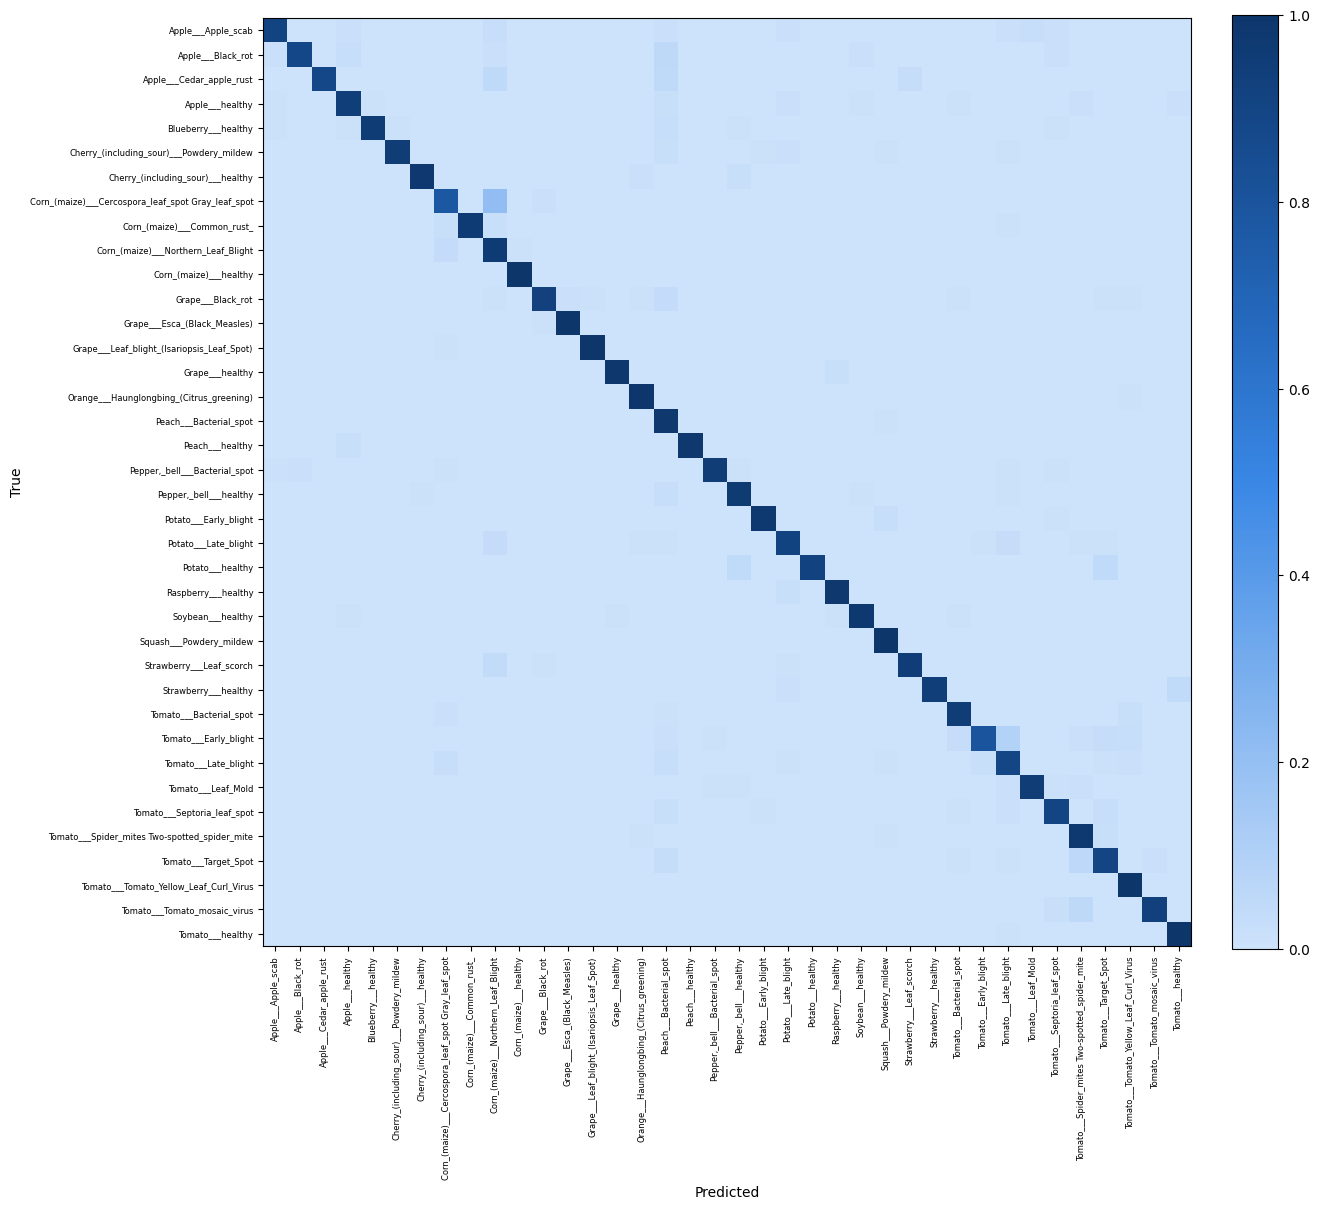

In [20]:
plot_confusion_matrix(test_metrics_aug["confusion_matrix"], class_names)
plt.tight_layout()
plt.show()

### Per-class recall vs. baseline

Direct comparison against the plain baseline (not the BatchNorm variant) -- same
test set, same classes, isolating augmentation's own effect.

In [21]:
recall_series_aug = pd.Series(
    test_metrics_aug["per_class_recall"], index=[idx_to_class[i] for i in range(num_classes)]
)

recall_comparison_aug = pd.DataFrame({
    "baseline_recall": recall_series,
    "augmented_recall": recall_series_aug,
})
recall_comparison_aug["delta"] = recall_comparison_aug["augmented_recall"] - recall_comparison_aug["baseline_recall"]
recall_comparison_aug = recall_comparison_aug.sort_values("delta")

print(f"Baseline:  test accuracy={test_metrics['accuracy']:.4f} | test macro_f1={test_metrics['macro_f1']:.4f}")
print(f"Augmented: test accuracy={test_metrics_aug['accuracy']:.4f} | test macro_f1={test_metrics_aug['macro_f1']:.4f}")
print(f"\nTomato___Early_blight recall: baseline={recall_series['Tomato___Early_blight']:.3f} -> augmented={recall_series_aug['Tomato___Early_blight']:.3f}")

print("\nBiggest recall drops (augmented worse than baseline):")
print(recall_comparison_aug.head(5))
print("\nBiggest recall gains (augmented better than baseline):")
print(recall_comparison_aug.tail(5))

Baseline:  test accuracy=0.9682 | test macro_f1=0.9591
Augmented: test accuracy=0.9583 | test macro_f1=0.9475

Tomato___Early_blight recall: baseline=0.767 -> augmented=0.800

Biggest recall drops (augmented worse than baseline):
                                                    baseline_recall  \
Apple___Black_rot                                          0.978495   
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot         0.857143   
Tomato___Target_Spot                                       0.971429   
Strawberry___healthy                                       1.000000   
Tomato___Late_blight                                       0.940767   

                                                    augmented_recall     delta  
Apple___Black_rot                                           0.881720 -0.096774  
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot          0.779221 -0.077922  
Tomato___Target_Spot                                        0.900000 -0.071429  
Strawberry___health

Takeaways:

- **Augmented test accuracy: 95.83% | test macro-F1: 94.75%** (baseline: 96.82% /
  95.91%, BatchNorm: 97.31% / 96.45% -- augmentation is *worse* than baseline on both
  metrics, -0.99pp accuracy / -1.16pp macro-F1). Best val macro-F1 only reached
  0.9524 (epoch 25), below both other runs, and the val curve was visibly choppier
  epoch to epoch than the baseline or BatchNorm runs -- consistent with stronger
  augmentation adding training difficulty that this fixed 30-epoch budget didn't
  recover from, rather than reducing overfitting that wasn't really present in the
  baseline to begin with.
- **Mixed on the targeted hypothesis, net negative overall.**
  `Tomato___Early_blight` improved slightly (0.767 -> 0.800, +3.3pp -- far less than
  BatchNorm's +8.7pp), but `Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot` (the
  other targeted class) got *worse* (0.857 -> 0.779, -7.8pp, second-biggest drop of
  any class). Unlike BatchNorm, this isn't a "helps the target, costs elsewhere"
  tradeoff -- it's a fairly clean net negative.
- **Decision: dropped.** No change to `configs/config.yaml` -- the Phase 2 default
  augmentation stays as the fixed baseline through Phase 8. Still a useful result:
  it ruled out a plausible-sounding idea with real evidence instead of assumption.
- Next: depth variant, built on top of BatchNorm only (not augmentation, per this
  result) -- the last of the three planned iterations before Phase 5.

## Iteration 3 — Depth (on top of BatchNorm)

Testing `SimpleCNNBatchNormDeep` (`src/models/cnn.py`) -- `SimpleCNNBatchNorm` plus
one more conv block (128 -> 256 channels, 28 -> 14 spatial), continuing the same
doubling/halving pattern the first three blocks already use. Built **on top of
BatchNorm, not the plain baseline** -- per the Iteration 1 decision -- and **not**
combined with stronger augmentation, since that was dropped in Iteration 2. Same
data (`loaders`, the original unaugmented dataloaders), same loss, same optimizer
config, same `max_epochs`/early-stopping settings. Run name
`phase4_simplecnn_batchnorm_deep`.

This is the last of the three planned iterations -- once this result is in, Phase 4
is done and ready to compare against in `PHASES.md`, and we move to Phase 5.

In [22]:
from src.models.cnn import SimpleCNNBatchNormDeep

model_deep = SimpleCNNBatchNormDeep(num_classes).to(device)
print(f"Parameters: {sum(p.numel() for p in model_deep.parameters()):,}")

optimizer_deep = torch.optim.Adam(model_deep.parameters(), lr=1e-3)

Parameters: 398,662


In [23]:
checkpoints_dir_deep = Path(cfg["logging"]["checkpoints_dir"]) / "phase4_simplecnn_batchnorm_deep"
resume_path_deep = checkpoints_dir_deep / "last.pt"
if resume_path_deep.exists():
    print(f"Found checkpoint from an earlier attempt, resuming from {resume_path_deep}")

history_deep = train_model(
    model_deep, loaders, criterion, optimizer_deep, device,
    run_name="phase4_simplecnn_batchnorm_deep", cfg=cfg, class_to_idx=class_to_idx, max_epochs=30,
    resume_from=resume_path_deep if resume_path_deep.exists() else None,
)
pd.DataFrame(history_deep)

train:   0%|          | 0/1188 [00:00<?, ?it/s]

eval:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 0: train_loss=1.1015 val_loss=0.6595 val_acc=0.7864 val_macro_f1=0.7193 (238.3s)


train:   0%|          | 0/1188 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a7e7b1ca40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a7e7b1ca40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a7e7b1ca40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x78a7e7b1ca40>self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
if w.is_alive():    
self._shutdown_workers()
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      if w.is_alive(): 
    ^^ ^ ^ ^ ^ ^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^^assert self._parent_pid == os.getpid(), 'can only test a child process'
^ ^ ^ 
    File "/usr/lib/p

eval:   0%|          | 0/255 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a7e7b1ca40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a7e7b1ca40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 29: train_loss=0.0355 val_loss=0.0352 val_acc=0.9885 val_macro_f1=0.9854 (255.3s)


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,lr,epoch_time_sec
0,0,1.101472,0.659475,0.786398,0.719286,0.001,238.286006
1,1,0.476839,0.284754,0.914805,0.891917,0.001,237.920823
2,2,0.324663,0.263940,0.918119,0.893267,0.001,236.644588
3,3,0.251632,0.187170,0.935060,0.911615,0.001,236.252757
4,4,0.207862,0.155139,0.951019,0.934279,0.001,237.140908
5,5,0.170801,0.192233,0.934078,0.915812,0.001,245.654530
6,6,0.150972,0.168812,0.945372,0.929853,0.001,238.147865
7,7,0.132536,0.085835,0.972134,0.964224,0.001,242.204144
8,8,0.118707,0.126082,0.957280,0.940812,0.001,240.042183
9,9,0.110496,0.089282,0.972011,0.968713,0.001,244.091298


### Verify checkpoint round-trip, then evaluate on the held-out test set

Same check as the previous runs, evaluated on the baseline's own `loaders["test"]`.

In [24]:
best_path_deep = checkpoints_dir_deep / "best.pt"
assert best_path_deep.exists()

fresh_model_deep = SimpleCNNBatchNormDeep(num_classes).to(device)
payload_deep = load_checkpoint(best_path_deep, fresh_model_deep, optimizer=None, map_location=device)
assert payload_deep["class_to_idx"] == class_to_idx, "class_to_idx did not round-trip!"
print(f"Reloaded checkpoint from epoch {payload_deep['epoch']}, best val {cfg['training']['checkpoint_metric']}={payload_deep['best_metric']:.4f}")

test_metrics_deep = engine.evaluate(fresh_model_deep, loaders["test"], criterion, device, num_classes)
print(f"Test accuracy: {test_metrics_deep['accuracy']:.4f} | Test macro_f1: {test_metrics_deep['macro_f1']:.4f}")

Reloaded checkpoint from epoch 26, best val macro_f1=0.9889


eval:   0%|          | 0/255 [00:00<?, ?it/s]

Test accuracy: 0.9897 | Test macro_f1: 0.9846


### Confusion matrix (test set)

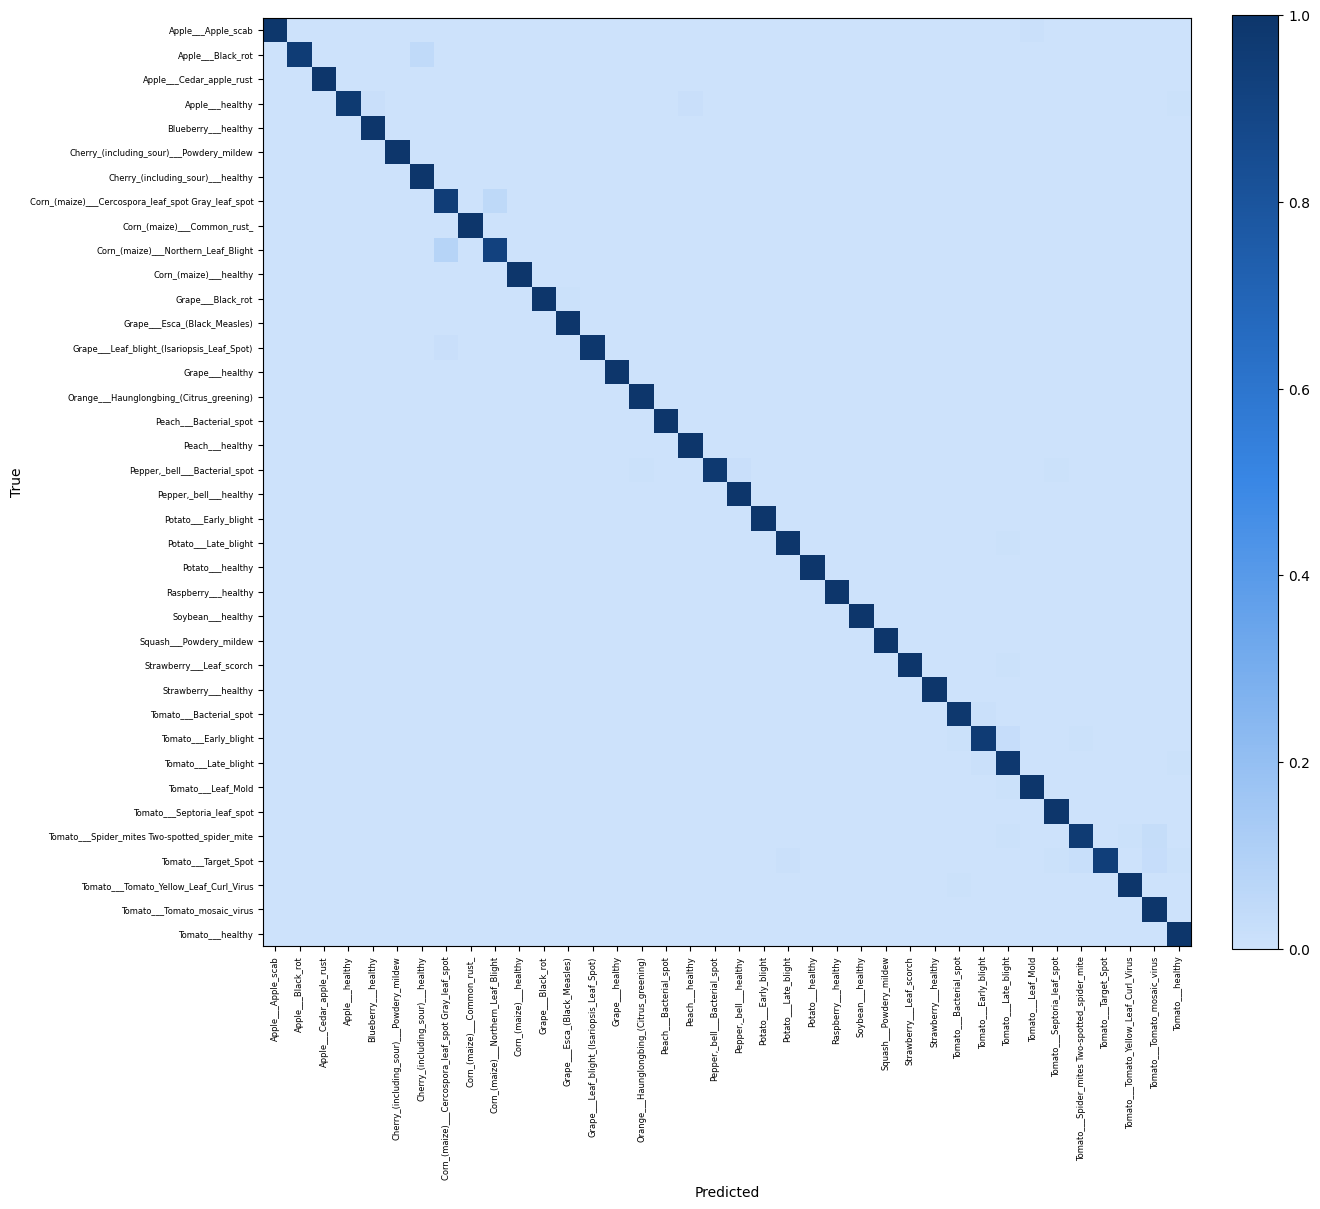

In [25]:
plot_confusion_matrix(test_metrics_deep["confusion_matrix"], class_names)
plt.tight_layout()
plt.show()

### Per-class recall vs. baseline and BatchNorm

Two comparisons: total improvement since the original baseline, and -- the more
informative one, since this variant builds directly on it -- what depth added *on
top of* BatchNorm specifically.

In [26]:
recall_series_deep = pd.Series(
    test_metrics_deep["per_class_recall"], index=[idx_to_class[i] for i in range(num_classes)]
)

recall_comparison_deep = pd.DataFrame({
    "baseline_recall": recall_series,
    "batchnorm_recall": recall_series_bn,
    "batchnorm_deep_recall": recall_series_deep,
})
recall_comparison_deep["delta_vs_bn"] = recall_comparison_deep["batchnorm_deep_recall"] - recall_comparison_deep["batchnorm_recall"]
recall_comparison_deep = recall_comparison_deep.sort_values("delta_vs_bn")

print(f"Baseline:       test accuracy={test_metrics['accuracy']:.4f} | test macro_f1={test_metrics['macro_f1']:.4f}")
print(f"BatchNorm:      test accuracy={test_metrics_bn['accuracy']:.4f} | test macro_f1={test_metrics_bn['macro_f1']:.4f}")
print(f"BatchNorm+Deep: test accuracy={test_metrics_deep['accuracy']:.4f} | test macro_f1={test_metrics_deep['macro_f1']:.4f}")

print(
    f"\nTomato___Early_blight recall: baseline={recall_series['Tomato___Early_blight']:.3f} "
    f"-> batchnorm={recall_series_bn['Tomato___Early_blight']:.3f} "
    f"-> batchnorm+deep={recall_series_deep['Tomato___Early_blight']:.3f}"
)

print("\nBiggest recall drops vs. BatchNorm (deep worse):")
print(recall_comparison_deep.head(5))
print("\nBiggest recall gains vs. BatchNorm (deep better):")
print(recall_comparison_deep.tail(5))

Baseline:       test accuracy=0.9682 | test macro_f1=0.9591
BatchNorm:      test accuracy=0.9731 | test macro_f1=0.9645
BatchNorm+Deep: test accuracy=0.9897 | test macro_f1=0.9846

Tomato___Early_blight recall: baseline=0.767 -> batchnorm=0.853 -> batchnorm+deep=0.960

Biggest recall drops vs. BatchNorm (deep worse):
                                                    baseline_recall  \
Apple___Black_rot                                          0.978495   
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot         0.857143   
Tomato___Target_Spot                                       0.971429   
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)                 0.987654   
Corn_(maize)___Common_rust_                                0.966480   

                                                    batchnorm_recall  \
Apple___Black_rot                                           0.989247   
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot          0.961039   
Tomato___Target_Spot                  

Takeaways:

- **BatchNorm+Deep test accuracy: 98.97% | test macro-F1: 98.46%** (baseline: 96.82%
  / 95.91%, BatchNorm: 97.31% / 96.45% -- +1.66pp accuracy / +2.01pp macro-F1 over
  BatchNorm alone, +2.15pp / +2.55pp over the original baseline). Best val macro-F1
  0.9889 at epoch 26. Train loss (0.0355) and val loss (0.0352) essentially identical
  at epoch 29 -- no overfitting despite ~4x the parameters (98K -> 399K).
- **Depth clearly added on top of BatchNorm, not just re-derived the same gain.**
  `Tomato___Early_blight` recall: 0.767 -> 0.853 -> **0.960** -- both changes helped,
  and depth added more capacity on top of what BatchNorm's stability already bought.
  Also partially recovered one of BatchNorm's own regressions:
  `Corn_(maize)___Northern_Leaf_Blight` went 0.946 (baseline) -> 0.816 (BatchNorm's
  dip) -> 0.918 (BatchNorm+Deep) -- most of the way back, though not fully. The small
  drops vs. BatchNorm alone (`Apple___Black_rot` -3.2pp, a few others under 1.5pp)
  are minor next to the gains elsewhere.
- **The imbalance question is now about as resolved as it's going to get.**
  `Potato___healthy` -- the original 36x-imbalance's smallest class at only 106 train
  images -- is at **100% recall** in this run. Not through weighted loss or
  `make_weighted_sampler` (never adopted) -- capacity and training stability turned
  out to matter more for this dataset's actual failure mode (confusing similar
  diseases) than raw class frequency did.
- **Final decision for Phase 4: `SimpleCNNBatchNormDeep` (`phase4_simplecnn_batchnorm_deep`)
  is "the" Phase 4 result carried into the Phase 8 comparison.** Clear winner across
  both metrics, no overfitting red flags, and it's the only variant that directly
  addresses the weakness the Phase 4 baseline's own confusion matrix identified.

## Phase 4 complete

All three planned iterations (batchnorm, augmentation, depth) ran with real results:
BatchNorm kept, augmentation dropped, depth (on BatchNorm) adopted as the final
result. See `PHASES.md` for the full writeup. Next: Phase 5 (transfer learning,
feature extraction).